<a href="https://colab.research.google.com/github/Josiah-Kunz/MGN-Public/blob/colab-examples/examples/colab/1_basic_tools/2_loads_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture

try:
    import google.colab  # noqa: F401
except ImportError:
    import ufl_legacy
    import fenics
else:
    try:
        import ufl_legacy
        import fenics
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
        import ufl_legacy
        import fenics

!apt-get install -y libglu1-mesa -q
!pip install meshgraphnet -q

import os
from meshgraphnet import MeshObject, Units, LoadCollection, VolumeLoad, SurfaceLoad, EdgeLoad

!wget "https://raw.githubusercontent.com/Josiah-Kunz/MGN-Public/refs/heads/colab-examples/examples/local/cantilever/geometries/cantilever.stp" -O "cantilever.stp" -q

In [2]:
def main():

    # The units don't have to agree with the mesh units (see below, mesh units are mm)
    # Volume/pressures *do* use the mesh's units, so they'd be in lbf/mm^3 and lbf/mm^2
    loads = LoadCollection(Units.US)

    # Volume loads are throughout the entire body of the mesh (2d or 3d) and affect every node
    # They accept arguments that are force per unit volume (or unit area for 2D)
    loads.add(VolumeLoad((0, -1e-4, 0)))  # Gravity in N/mm^2 since mesh is in mm and is 2D

    # Surface loads have pre-defined locations, like "right", or you can describe the location via lambda
    # You can either input total force or pressure
    loads.add(SurfaceLoad('right', pressure=(5, 0, 0), name='Distributed right load'))  # Applied force in psi

    # Edge loads can similarly be total force or per length
    # Edge loads only support lambda functions (no pre-defined locations)
    # In 2D, you shouldn't really use edge loads, though, since stress is a 3D quantity and thickness hasn't been defined
    """
    loads.add(EdgeLoad(
        location=lambda x, on_boundary: on_boundary and x[1] > 499,  # Top edge (y ~ 500)
        load_per_length=(0, -0.15, 0),  # N/mm downward
        name="Distributed top load"
    ))
    """

    # Get a mesh to load
    mesh = MeshObject("cantilever.stp", 250, units=Units.SI_MM, force_2d=True)

    # Display total forces
    for load in loads.loads:
        print(f"Total load for \"{load.get_display_name()}\": {load.get_magnitude(mesh)} {loads.units.get_force_unit():~}")

    # Visualize
    loads.visualize(mesh, arrow_scale=0.5, legend=False)

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_220e2b938e27b45e22eeef8611798b73b680a5a0

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.



Total load for "Volume Load": 2500.0 lbf


INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of exterior_facet subdomains: 2
  Rank:                                0
  Arguments:                           '()'
  Number of coefficients:              1
  Coefficients:                        '[f_8]'
  Unique elements:                     'R0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:                 'R0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0878172 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 0 elements
INFO:FFC:  Computing representation of 0 dofmaps
INFO:FFC:  Computing representation of 0 coo

Total load for "Distributed right load": 5000.0 lbf


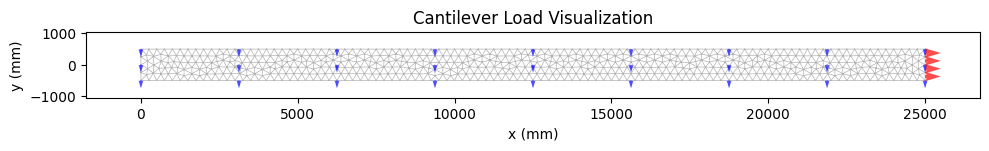

In [3]:
if __name__ == "__main__":
    main()